# 08 JUNE 2026

In [65]:
import pandas as pd
import numpy as np
import shap
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
                                        train_test_split,
                                        StratifiedKFold,
                                        cross_validate
                                    )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
                                RandomForestClassifier,
                                GradientBoostingClassifier,
                                StackingClassifier
                            )
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# PreProcessing

In [66]:
df = pd.read_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\bank-full.csv", sep=';')

df_copy = df.copy()

def data_clean(df):
    df.drop('duration', axis=1, inplace=True)

    # *******ENCODING for categorical variables*********
    # One-hot encoding for 'job', 'marital', 'contact', 'month', 'poutcome' columns
    df = pd.get_dummies(df,columns=['job','marital','contact','month','poutcome'],dtype='int',drop_first=True)

    # Ordinal encoding for 'education' column
    maping = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
    df['education'] = df['education'].map(maping)

    # Label encoding for 'default', 'housing', 'loan', 'y' columns
    label_encoding_cols = ['default','housing','loan', 'y']
    encoder = LabelEncoder()
    for col in label_encoding_cols:
        df[col] = encoder.fit_transform(df[col])

    # ******* FEATURE ENGINNERING *********
    df['age_balance'] = df['age'] * df['balance']
    df['contacted_before'] = np.where(df['previous'] > 0, 1, 0)
    df['total_loans'] = (df['housing']+ df['loan'])

    # ******* FEATURES & TARGET VARIABLE SEPARATION *********
    X = df.drop('y', axis=1)
    y = df['y']

    return X, y

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# Train Test split

In [67]:
X, y = data_clean(df_copy)

# ******* Train-test Split *********
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# ******* Scaling for numerical variables*********
scaler = RobustScaler()
numerical_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols)
X_train = pd.concat([X_train_scaled, X_train.drop(numerical_cols, axis=1).reset_index(drop=True)], axis=1)

X_test_scaled = scaler.transform(X_test[numerical_cols])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols)
X_test = pd.concat([X_test_scaled, X_test.drop(numerical_cols, axis=1).reset_index(drop=True)], axis=1)

# ******* Handling Imbalanced Data using SMOTE *********
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(63874, 42)
(63874,)
(9043, 42)
(9043,)


# Classification Model

In [12]:
models = [LogisticRegression(solver='liblinear',max_iter=5000,random_state=42),
          RandomForestClassifier(n_estimators=100,random_state=42),
          GradientBoostingClassifier(random_state=42),
          XGBClassifier(eval_metric='logloss',random_state=42),
          LGBMClassifier(random_state=42),
          CatBoostClassifier(verbose=0,random_state=42),
          GaussianNB(),
          SVC(probability=True,random_state=42)
          ]
results = []

for model in models:
    model.fit(X_train,y_train)

    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:,1]
    print(f"********Train*********")
    print(type(model).__name__)
    results.append((type(model).__name__, 
                    "Train",
                    accuracy_score(y_train, train_pred), 
                    precision_score(y_train, train_pred), 
                    recall_score(y_train, train_pred), 
                    f1_score(y_train, train_pred), 
                    roc_auc_score(y_train, train_prob)))

    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:,1]    
    print(f"********Test*********")
    results.append((type(model).__name__, 
                    "Test",
                    accuracy_score(y_test, test_pred), 
                    precision_score(y_test, test_pred), 
                    recall_score(y_test, test_pred), 
                    f1_score(y_test, test_pred), 
                    roc_auc_score(y_test, test_prob)))
    
    
result_df = pd.DataFrame(results,columns=["Model","Train/Test","Accuracy","Precision","Recall","F1","ROC_AUC"])
result_df

********Train*********
LogisticRegression
********Test*********
********Train*********
RandomForestClassifier
********Test*********
********Train*********
GradientBoostingClassifier
********Test*********
********Train*********
XGBClassifier
********Test*********
[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
********Train*********
LGBMClassifier
********Test*********
********Train*********
CatBoostClassifier
********Test*********
********Train*********
GaussianNB
********Test*********
********Train*********
SVC
********Test*********


,Model,Train/Test,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,Train,0.642264,0.713741,0.475060,0.570440,0.768175
1,LogisticRegression,Test,0.764790,0.229093,0.427221,0.298251,0.695622
2,RandomForestClassifier,Train,0.999984,1.000000,0.999969,0.999984,1.000000
3,RandomForestClassifier,Test,0.882451,0.496160,0.305293,0.377999,0.779273
4,GradientBoostingClassifier,Train,0.915913,0.933235,0.895920,0.914197,0.962947
5,GradientBoostingClassifier,Test,0.871613,0.443593,0.382798,0.410959,0.774780
6,XGBClassifier,Train,0.951561,0.977170,0.924727,0.950225,0.985297
7,XGBClassifier,Test,0.885989,0.520362,0.326087,0.400930,0.783231
8,LGBMClassifier,Train,0.934887,0.965262,0.902245,0.932690,0.976295
9,LGBMClassifier,Test,0.887648,0.534314,0.309074,0.391617,0.786826


In [13]:
result_df.to_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\Metrics_Comparision.csv")

In [ ]:
''''Among the evaluated machine learning models, CatBoost achieved the best overall performance with a test ROC-AUC score of 0.788, 
an accuracy of 88.70%, and a precision of 52.87%.
While Gradient Boosting achieved the highest recall (38.28%) and F1-score (41.09%),
CatBoost demonstrated superior discrimination capability and generalization performance. 

Random Forest showed signs of severe overfitting with nearly perfect training metrics but lower test performance. 
Therefore, CatBoost was selected as the final model for deployment due to its strong predictive performance
and robustness in handling the imbalanced term deposit subscription dataset. '''

# Stacking

In [27]:
base_models = [
                ('xgb', XGBClassifier(random_state=42,eval_metric='logloss')),
                ('lgbm',LGBMClassifier(random_state=42)),
                ('cat',CatBoostClassifier(verbose=0,random_state=42))
            ]
stack_model = StackingClassifier(estimators=base_models,final_estimator=LogisticRegression(),cv=5,n_jobs=-1)
# Training
stack_model.fit(X_train, y_train)
# Prediction
y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7985
           1       0.50      0.39      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.67      0.69      9043
weighted avg       0.87      0.88      0.88      9043

0.7898850988325228


In [ ]:
''' A Stacking Classifier was developed using XGBoost, LightGBM, and CatBoost as base learners 
with Logistic Regression as the meta-learner. 
The stacking approach achieved a ROC-AUC score of 0.7899, outperforming individual models while 
improving recall from 31% to 39% and F1-score from 39% to 44%. 
Therefore, the Stacking Classifier was selected as the final model for deployment. '''

# Blending

In [5]:
xgb_model = XGBClassifier(random_state=42,eval_metric='logloss')
lgbm_model = LGBMClassifier(random_state=42)
cat_model = CatBoostClassifier(verbose=0,random_state=42)

# Training
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]
lgbm_prob = lgbm_model.predict_proba(X_test)[:,1]
cat_prob = cat_model.predict_proba(X_test)[:,1]

blend_prob = (
                0.25 * xgb_prob +
                0.25 * lgbm_prob +
                0.5 * cat_prob
            )

blend_pred = (blend_prob >= 0.5).astype(int)
print(classification_report(y_test,blend_pred))
print(roc_auc_score(y_test,blend_prob))

[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7985
           1       0.54      0.31      0.40      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.64      0.67      9043
weighted avg       0.87      0.89      0.88      9043

0.7913238787755397


In [ ]:
''' Multiple machine learning algorithms were evaluated, including Logistic Regression, Random Forest, Gradient Boosting, 
XGBoost, LightGBM, CatBoost, Gaussian Naive Bayes, and Support Vector Classifier. 
CatBoost achieved the highest ROC-AUC score among individual models (0.788). 
To further improve performance, ensemble approaches using Blending and Stacking were developed. 
The Stacking Classifier achieved the best balance between precision and recall with an F1-score of 0.44 
and a ROC-AUC of approximately 0.79. 
Therefore, the Stacking Classifier was selected as the final model for deployment in the term deposit subscription prediction system.'''

# Stratified K-Fold cross-validation

In [ ]:
''' Stratified 5-Fold Cross-Validation further demonstrated stable performance, 
confirming the model's robustness and generalization capability.'''

In [16]:
#df = pd.read_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\bank-full.csv", sep=';')

#df_copy = df.copy()

#X, y = data_clean(df_copy)
#smote = SMOTE()
#X, y = smote.fit_resample(X, y)

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {
            'accuracy':'accuracy',
            'precision':'precision',
            'recall':'recall',
            'f1':'f1',
            'roc_auc':'roc_auc'
          }

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_model)
])

cv_results = cross_validate(
                                pipeline,
                                X,
                                y,
                                cv=skf,
                                scoring=scoring,
                                n_jobs=-1
                            )
for metric in scoring.keys():
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"{metric}: {mean_score:.4f} (+/- {std_score:.4f})")

accuracy: 0.8726 (+/- 0.0083)
precision: 0.8981 (+/- 0.0180)
recall: 0.8411 (+/- 0.0052)
f1: 0.8685 (+/- 0.0072)
roc_auc: 0.8737 (+/- 0.0106)


# Feature Importance

In [19]:
importance_cat = pd.DataFrame({
                                    'Feature': X_train.columns,
                                    'Importance': cat_model.feature_importances_
                                })

importance_cat = importance_cat.sort_values(
                                                by='Importance',
                                                ascending=False
                                            )

print(importance_cat.head(10))

             Feature  Importance
2           campaign   47.279625
0                age   12.244674
4           previous    6.010504
40  contacted_before    4.906925
3              pdays    2.876441
24   contact_unknown    2.330710
25         month_aug    2.119481
32         month_may    1.845183
9                day    1.812121
29         month_jul    1.730760


In [20]:
importance_xgb = pd.DataFrame({
                                    'Feature': X_train.columns,
                                    'Importance': xgb_model.feature_importances_
                                })

importance_xgb = importance_xgb.sort_values(
                                                by='Importance',
                                                ascending=False
                                            )

print(importance_xgb.head(10))

             Feature  Importance
38  poutcome_unknown    0.089168
24   contact_unknown    0.087064
25         month_aug    0.083268
41       total_loans    0.077458
33         month_nov    0.074845
27         month_feb    0.050559
28         month_jan    0.047486
7            housing    0.040612
29         month_jul    0.037559
30         month_jun    0.031435


In [21]:
importance_lgbm = pd.DataFrame({
                                    'Feature': X_train.columns,
                                    'Importance': lgbm_model.feature_importances_
                                })

importance_lgbm = importance_lgbm.sort_values(
                                                by='Importance',
                                                ascending=False
                                            )

print(importance_lgbm.head(10))

            Feature  Importance
0               age         311
2          campaign         291
9               day         283
39      age_balance         204
1           balance         190
3             pdays         179
4          previous         114
24  contact_unknown          97
29        month_jul          91
25        month_aug          75


In [ ]:
''' Feature importance analysis was conducted using CatBoost, XGBoost, and LightGBM models. 
Campaign-related variables (campaign, previous, and pdays) emerged as the strongest predictors of term deposit subscription. 
Engineered features such as Age-Balance Interaction (age_balance), Previous Contact Indicator (contacted_before), 
and Total Loans (total_loans) ranked among the most influential features across multiple models. 
This demonstrates that feature engineering successfully enhanced the predictive power of the dataset 
and contributed to the performance of the final ensemble model.'''

# SHAP for model explainability

In [ ]:
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
                    shap_values,
                    X_test,
                    plot_type='dot'
                )

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
                    shap_values,
                    X_test,
                    plot_type='dot'
                )

c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


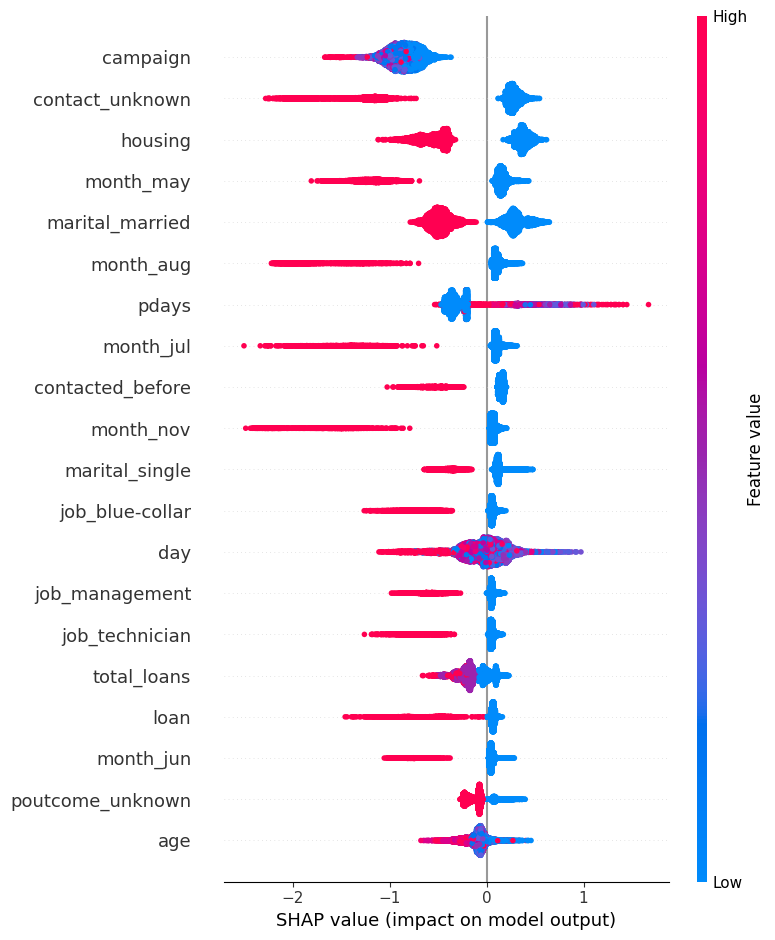

In [35]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
                    shap_values,
                    X_test,
                    plot_type='dot'
                )

# Save the model

In [39]:
joblib.dump(stack_model,"bank_term_deposit_model.pkl")

print("Model saved as bank_term_deposit_model.pkl")

Model saved as bank_term_deposit_model.pkl


In [55]:
joblib.dump(cat_model,"bank_term_deposit_cat_model.pkl")

print("Model saved as bank_term_deposit_cat_model.pkl")

Model saved as bank_term_deposit_cat_model.pkl


# Prediction

In [50]:
model = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\bank_term_deposit_model.pkl")

prediction = model.predict(
    X_test.iloc[[0]]
)

probability = model.predict_proba(
    X_test.iloc[[0]]
)

pred = prediction[0]

prob_no = probability[0][0]
prob_yes = probability[0][1]

if pred == 1:
    print("Customer likely to subscribe.")
    print(f"Probability: {prob_yes:.2%}")
else:
    print("Customer unlikely to subscribe.")
    print(f"Probability: {prob_no:.2%}")

Customer unlikely to subscribe.
Probability: 91.73%


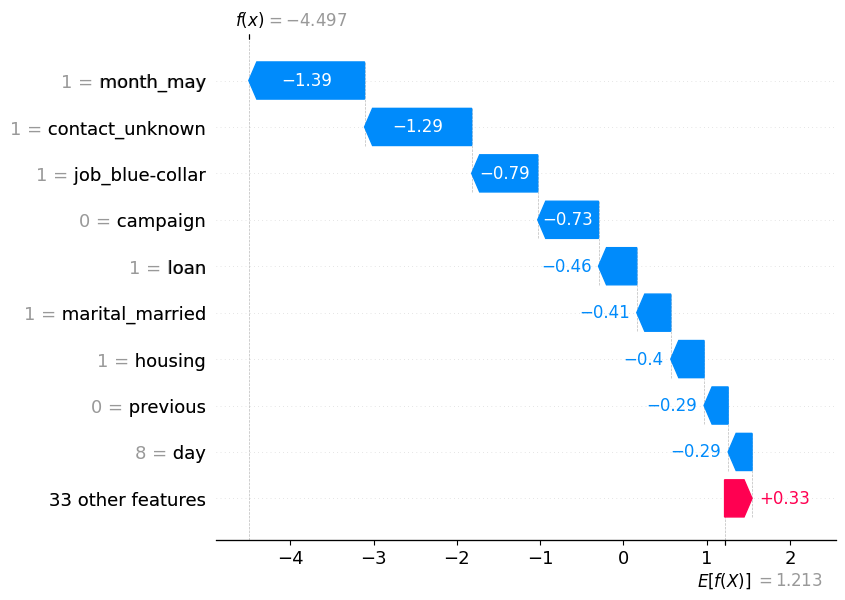

In [47]:
explainer = shap.TreeExplainer(cat_model)
sample = X_test.iloc[[0]]
shap_values = explainer.shap_values(sample)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

In [51]:
predictions = model.predict(X_test)

positive_indices = np.where(predictions == 1)[0]

if len(positive_indices) > 0:
    idx = positive_indices[0]

    print("Index:", idx)

    print("Prediction:",
          model.predict(X_test.iloc[[idx]])[0])

    print("Probability:",
          model.predict_proba(X_test.iloc[[idx]]))

Index: 7
Prediction: 1
Probability: [[0.16914111 0.83085889]]


In [62]:
model = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\bank_term_deposit_cat_model.pkl")

# Manual input (example values)
customer = {
    'age': 20,
    'balance': 25000000,
    'campaign': 2,
    'pdays': 999,
    'previous': 0,
    'day': 15,

    'default': 0,
    'housing': 0,
    'loan': 0,

    'education': 2,

    'job_blue-collar': 0,
    'job_entrepreneur': 0,
    'job_housemaid': 0,
    'job_management': 1,
    'job_retired': 0,
    'job_self-employed': 0,
    'job_services': 0,
    'job_student': 0,
    'job_technician': 0,
    'job_unemployed': 0,
    'job_unknown': 0,

    'marital_married': 1,
    'marital_single': 0,

    'contact_telephone': 0,
    'contact_unknown': 0,

    'month_aug': 0,
    'month_dec': 0,
    'month_feb': 1,
    'month_jan': 0,
    'month_jul': 0,
    'month_jun': 0,
    'month_mar': 0,
    'month_may': 0,
    'month_nov': 0,
    'month_oct': 0,
    'month_sep': 0,

    'poutcome_other': 0,
    'poutcome_success': 0,
    'poutcome_unknown': 1
}

# Feature engineering
customer['age_balance'] = customer['age'] * customer['balance']
customer['contacted_before'] = 1 if customer['previous'] > 0 else 0
customer['total_loans'] = customer['housing'] + customer['loan']

# Convert to DataFrame
customer_df = pd.DataFrame([customer])

# Predict
prediction = model.predict(customer_df)[0]
probability = model.predict_proba(customer_df)[0]

print("Prediction:", prediction)
print(f"No Subscription Probability: {probability[0]:.2%}")
print(f"Subscription Probability: {probability[1]:.2%}")

if prediction == 1:
    print("Customer is likely to subscribe.")
else:
    print("Customer is unlikely to subscribe.")

Prediction: 0
No Subscription Probability: 52.10%
Subscription Probability: 47.90%
Customer is unlikely to subscribe.
